<a href="https://colab.research.google.com/github/nmwiley808/csci164/blob/main/project/csci164_Final_Project_Applied_Machine_Learning_w_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Machine Learning - Final Project

Course: CSCI 164 | Noah Wiley | Spring 2026

---

# Overview
This notebook walks through a complete machine learning workflow using Python and sckikit-learn across two real-world datasets

---

# Dataset 1 - Titanic Survival (Classification)
Using passenger data such such as age, sex, class, and fare. We can predict wheether a passenger survived. This is a binary classification problem.

# Dataset 2 - California Housing Prices (Regression)
Using census-level features like median income and location, we predict median house values. This is a regression problem.

---

# What to Expect
1. **Imports & Setup** – Load all necessary libraries
2. **Dataset 1: Titanic** – Load, explore, and preprocess the data
3. **Titanic Models** – Train Logistic Regression, Decision Tree, and k-NN
4. **Titanic Evaluation** – Confusion matrices, ROC curves, metrics comparison
5. **Titanic Tuning** – Optimize models using GridSearchCV
6. **Dataset 2: California Housing** – Load, explore, and preprocess the data
7. **Housing Models** – Train Linear Regression, Decision Tree, and k-NN
8. **Housing Evaluation** – Scatter plots, residual plots, metrics comparison
9. **Housing Tuning** – Optimize models using GridSearchCV
10. **Final Dashboard** – Side-by-side comparison of all models

---

# How to Run
Run each cell from top to bottom in order. All libraries are pre-installed in Google Colab.

In [ ]:
# Setup

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


In [ ]:
# Load Titanic via seaborn's built-in copy - no Kaggle Key needed
titanic_raw = sns.load_dataset('titanic')
print(titanic_raw.shape)
titanic_raw.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:
 survived         0
pclass           0
sex              0

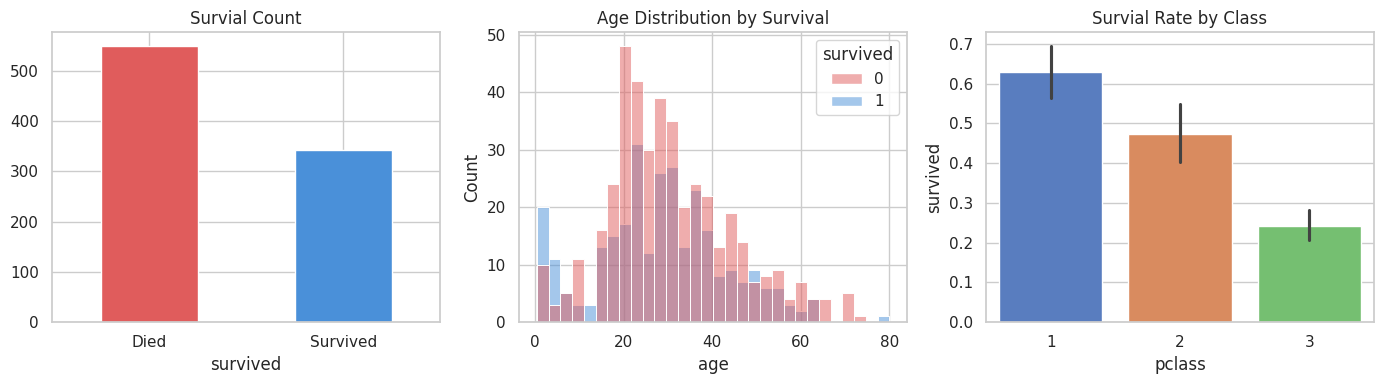

In [ ]:
# Titanic Explore

print(titanic_raw.info())
print("\nMissing values:\n", titanic_raw.isnull().sum())
print("\nSurvival rate:", titanic_raw['survived'].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14,4))

titanic_raw['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e05c5c', '#4a90d9'])
axes[0].set_title('Survial Count')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

sns.histplot(data=titanic_raw, x='age', hue='survived', bins=30, ax=axes[1], palette=['#e05c5c','#4a90d9'])
axes[1].set_title('Age Distribution by Survival')

sns.barplot(data=titanic_raw, x='pclass', y='survived', ax=axes[2], palette='muted')
axes[2].set_title('Survial Rate by Class')

plt.tight_layout()
plt.show()

In [ ]:
# Titanic: Preprocessing

df_t = titanic_raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

df_t['age'].fillna(df_t['age'].median(), inplace=True)
df_t['fare'].fillna(df_t['fare'].median(), inplace=True)
df_t.dropna(inplace=True)

df_t['sex'] = df_t['sex'].map({'male': 0, 'female': 1})
df_t['embarked'] = df_t['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df_t['family_size'] = df_t['sibsp'] + df_t['parch']
df_t['is_alone'] = (df_t['family_size'] == 0).astype(int)

X_t = df_t.drop('survived', axis=1)
y_t = df_t['survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

print(f"Train size: {X_train_t.shape}, Test size: {X_test_t.shape}")
print(f"Class balance (train): {y_train_t.value_counts(normalize=True).round(3).to_dict()}")

Train size: (711, 9), Test size: (178, 9)
Class balance (train): {0: 0.617, 1: 0.383}


In [9]:
# Titanic: Train Three Models

clf_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'k-NN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train_t, y_train_t)
    y_pred  = model.predict(X_test_t)
    y_prob  = model.predict_proba(X_test_t)[:, 1]
    cv_scores = cross_val_score(model, X_t, y_t, cv=5, scoring='accuracy')
    clf_results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  accuracy_score(y_test_t, y_pred),
        'precision': precision_score(y_test_t, y_pred),
        'recall':    recall_score(y_test_t, y_pred),
        'f1':        f1_score(y_test_t, y_pred),
        'roc_auc':   roc_auc_score(y_test_t, y_prob),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
    }
    print(f"{name:22s} | Acc={clf_results[name]['accuracy']:.3f} "
          f"F1={clf_results[name]['f1']:.3f} "
          f"AUC={clf_results[name]['roc_auc']:.3f} "
          f"CV={clf_results[name]['cv_mean']:.3f}±{clf_results[name]['cv_std']:.3f}")

Logistic Regression    | Acc=0.815 F1=0.744 AUC=0.865 CV=0.792±0.016
Decision Tree          | Acc=0.747 F1=0.672 AUC=0.728 CV=0.774±0.021
k-NN                   | Acc=0.781 F1=0.702 AUC=0.832 CV=0.808±0.020


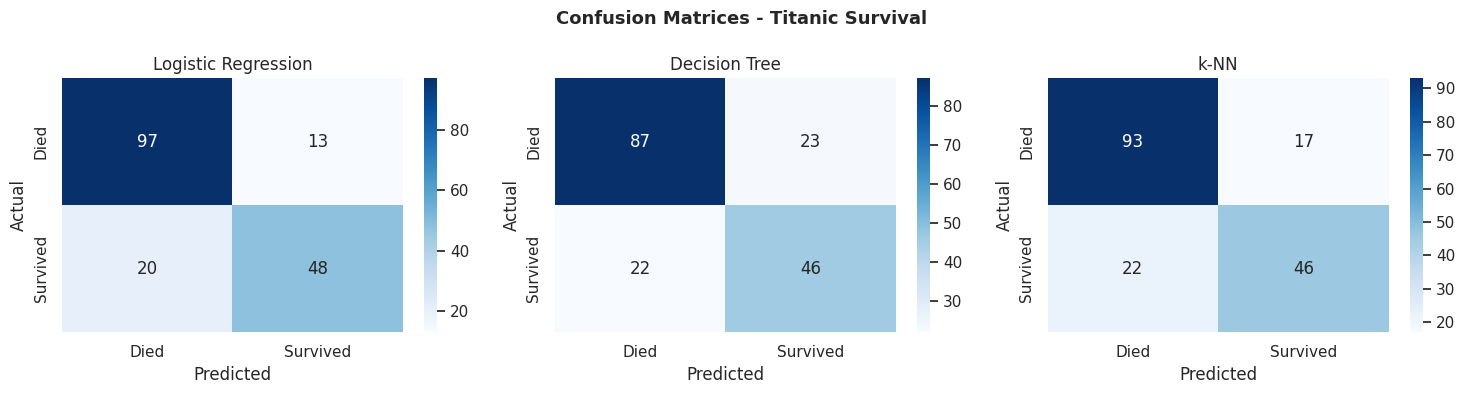

In [10]:
# Titanic: Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('Confusion Matrices - Titanic Survival', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, clf_results.items()):
  cm = confusion_matrix(y_test_t, res['y_pred'])
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
              xticklabels=['Died', 'Survived'],
              yticklabels=['Died', 'Survived'])
  ax.set_title(name)
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

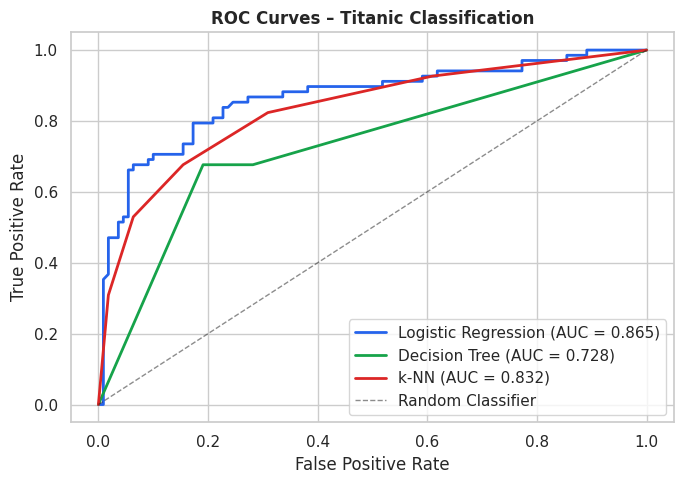

In [11]:
# Titanic: ROC Curves

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2563eb', '#16a34a', '#dc2626']

for (name, res), color in zip(clf_results.items(), colors):
  fpr, tpr, _ = roc_curve(y_test_t, res['y_prob'])
  ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC = {res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – Titanic Classification', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

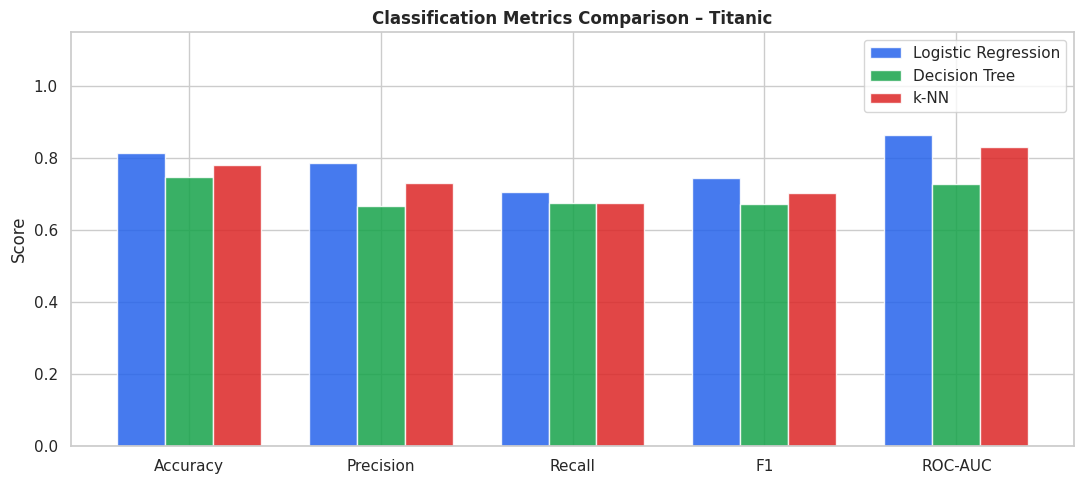

In [12]:
# Titanic: Metrics Bar Chart

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11,5))
for i, (name, color) in enumerate(zip(clf_results.keys(), colors)):
  vals = [clf_results[name][m] for m in metrics]
  ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Classification Metrics Comparison – Titanic', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Titanic: Hyperparameter Tuning

dt_param_grid = {
    'clf__max_depth': [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

gs_dt = GridSearchCV(clf_models['Decision Tree'], dt_param_grid,
                     cv = 5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train_t, y_train_t)
print("Best Decision Tree params:", gs_dt.best_params_)
print("Best CV accuracy:         ", round(gs_dt.best_score_, 4))

knn_param_grid = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(clf_models['k-NN'], knn_param_grid,
                      cv=5, scoring='accuracy', n_jobs=-1)
gs_knn.fit(X_train_t, y_train_t)
print("Best k-NN params:         ", gs_knn.best_params_)
print("Best CV accuracy:         ", round(gs_knn.best_score_, 4))

tuned_models = {
    'Decision Tree (Tuned)': gs_dt.best_estimator_,
    'k-NN (Tuned)':          gs_knn.best_estimator_
}
print("\nTuned model test-set results:")
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_t)
    y_prob = model.predict_proba(X_test_t)[:, 1]
    print(f"  {name:25s} | Acc={accuracy_score(y_test_t,y_pred):.3f} "
          f"F1={f1_score(y_test_t,y_pred):.3f} "
          f"AUC={roc_auc_score(y_test_t,y_prob):.3f}")

Best Decision Tree params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10}
Best CV accuracy:          0.8158
Best k-NN params:          {'clf__metric': 'manhattan', 'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
Best CV accuracy:          0.8115

Tuned model test-set results:
  Decision Tree (Tuned)     | Acc=0.770 F1=0.655 AUC=0.825
  k-NN (Tuned)              | Acc=0.787 F1=0.721 AUC=0.846


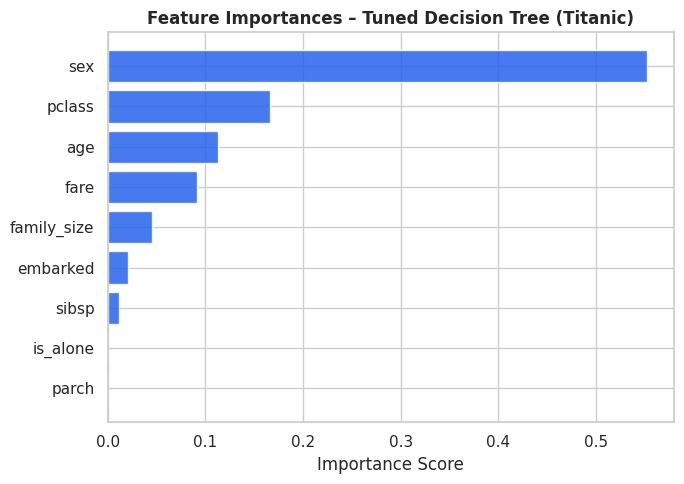

In [14]:
# Titanic: Feature Importances

best_dt_clf = gs_dt.best_estimator_
importances = best_dt_clf.named_steps['clf'].feature_importances_
feat_df = pd.DataFrame({'feature': X_t.columns, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feat_df['feature'], feat_df['importance'], color='#2563eb', alpha=0.85)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importances – Tuned Decision Tree (Titanic)', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Classification Summary Table

summary_rows = []
for name, res in clf_results.items():
    summary_rows.append({
        'Model':     name,
        'Accuracy':  round(res['accuracy'],  3),
        'Precision': round(res['precision'], 3),
        'Recall':    round(res['recall'],    3),
        'F1':        round(res['f1'],        3),
        'ROC-AUC':   round(res['roc_auc'],   3),
        'CV Mean':   round(res['cv_mean'],   3),
        'CV Std':    round(res['cv_std'],    3),
    })
for name, model in tuned_models.items():
    yp = model.predict(X_test_t)
    yprob = model.predict_proba(X_test_t)[:,1]
    cv = cross_val_score(model, X_t, y_t, cv=5, scoring='accuracy')
    summary_rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test_t,yp),3),
        'Precision': round(precision_score(y_test_t,yp),3),
        'Recall':    round(recall_score(y_test_t,yp),3),
        'F1':        round(f1_score(y_test_t,yp),3),
        'ROC-AUC':   round(roc_auc_score(y_test_t,yprob),3),
        'CV Mean':   round(cv.mean(),3),
        'CV Std':    round(cv.std(),3),
    })

clf_summary = pd.DataFrame(summary_rows)
print(clf_summary.to_string(index=False))

                Model  Accuracy  Precision  Recall    F1  ROC-AUC  CV Mean  CV Std
  Logistic Regression     0.815      0.787   0.706 0.744    0.865    0.792   0.016
        Decision Tree     0.747      0.667   0.676 0.672    0.728    0.774   0.021
                 k-NN     0.781      0.730   0.676 0.702    0.832    0.808   0.020
Decision Tree (Tuned)     0.770      0.765   0.574 0.655    0.825    0.818   0.029
         k-NN (Tuned)     0.787      0.721   0.721 0.721    0.846    0.799   0.031
